In [22]:
import numpy as np
import polars as pl
import lightgbm as lgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [23]:
DATA_PATH = "raw/processed_gtfs/baseline_dataset.parquet"
 
df = pl.read_parquet(DATA_PATH)
print(df.shape)
 
TARGET = "travel_time"
CATEGORICAL = ["route_id", "direction_id", "shape_id", "service_id"]
NUMERIC = [
    "stop_sequence", "trip_progress",
    "hour", "weekday", "month", "is_peak",
    "scheduled_arrival", "scheduled_departure", "scheduled_segment_time",
    "stop_lat", "stop_lon", "latitude", "longitude", "bearing",
]
FEATURES = CATEGORICAL + NUMERIC

(59768, 29)


In [24]:
groups = df["trip_id"].to_numpy()
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=groups))
 
train_df = df[train_idx]
test_df = df[test_idx]

 
print(f"train: {train_df.shape} | test: {test_df.shape}")
print(f"train trips: {train_df['trip_id'].n_unique():,} | "
      f"test trips: {test_df['trip_id'].n_unique():,} | "
      f"overlap: {len(set(train_df['trip_id']) & set(test_df['trip_id']))}")

train: (47588, 29) | test: (12180, 29)
train trips: 1,008 | test trips: 252 | overlap: 0


In [25]:
for c in FEATURES:
    print(c, train_df.schema[c])

route_id String
direction_id Int64
shape_id String
service_id String
stop_sequence UInt32
trip_progress Float64
hour Int8
weekday Int8
month Int8
is_peak Int8
scheduled_arrival Int32
scheduled_departure Int32
scheduled_segment_time Int32
stop_lat Float64
stop_lon Float64
latitude Float32
longitude Float32
bearing Float32


In [26]:
import pandas as pd
 
def to_pandas_typed(pl_df: pl.DataFrame) -> pd.DataFrame:
    # Built column-by-column from numpy instead of pl_df.to_pandas(), which
    # internally depends on pyarrow.Array - avoids environments where the
    # pyarrow install is broken/mismatched with the polars build.
    cols = {}
    for col in FEATURES:
        s = pl_df[col]
        if col in CATEGORICAL:
            cols[col] = pd.Series(s.to_list(), dtype="category")
        else:
            cols[col] = s.to_numpy()
    return pd.DataFrame(cols)
 
X_train = to_pandas_typed(train_df)
X_test = to_pandas_typed(test_df)
y_train = train_df[TARGET].to_numpy()
y_test = test_df[TARGET].to_numpy()

In [27]:
model = lgb.LGBMRegressor(
    objective="regression",
    metric="mae",
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=63,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)
 
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="mae",
    categorical_feature=CATEGORICAL,
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)],
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001265 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2454
[LightGBM] [Info] Number of data points in the train set: 47588, number of used features: 18
[LightGBM] [Info] Start training from score 98.087480
Training until validation scores don't improve for 50 rounds


c:\Users\ishan\anaconda3\envs\DL\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[100]	valid_0's l1: 38.0517
[200]	valid_0's l1: 36.4578
[300]	valid_0's l1: 35.7655
[400]	valid_0's l1: 35.3784
[500]	valid_0's l1: 35.243
[600]	valid_0's l1: 35.1342
[700]	valid_0's l1: 35.0317
Early stopping, best iteration is:
[735]	valid_0's l1: 34.9988


,num_leaves,63
,learning_rate,0.03
,n_estimators,2000
,objective,'regression'
,min_child_samples,30
,subsample,0.8
,colsample_bytree,0.8
,random_state,42
,metric,'mae'
,boosting_type,'gbdt'
,max_depth,-1


In [28]:
preds = model.predict(X_test, num_iteration=model.best_iteration_)
 
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)
 
print(f"MAE:  {mae:.1f} sec")
print(f"RMSE: {rmse:.1f} sec")
print(f"R2:   {r2:.4f}")
 
# naive baseline for comparison: predict the scheduled segment time as-is
naive_preds = test_df["scheduled_segment_time"].to_numpy()
naive_mae = mean_absolute_error(y_test, naive_preds)
print(f"\nNaive baseline (scheduled_segment_time only) MAE: {naive_mae:.1f} sec")
print(f"Improvement over naive: {(1 - mae / naive_mae) * 100:.1f}%")

MAE:  35.0 sec
RMSE: 73.5 sec
R2:   0.4298

Naive baseline (scheduled_segment_time only) MAE: 49.3 sec
Improvement over naive: 29.0%


In [29]:
importance = (
    pl.DataFrame({
        "feature": X_train.columns.tolist(),
        "importance": model.feature_importances_,
    })
    .sort("importance", descending=True)
)
print(importance)
 
# %%
# ---------------------------------------------------
# Save
# ---------------------------------------------------
 
model.booster_.save_model("models/lgbm_baseline.txt")
print("model saved")

shape: (18, 2)
┌────────────────────────┬────────────┐
│ feature                ┆ importance │
│ ---                    ┆ ---        │
│ str                    ┆ i32        │
╞════════════════════════╪════════════╡
│ scheduled_arrival      ┆ 7764       │
│ scheduled_segment_time ┆ 4378       │
│ stop_lat               ┆ 4316       │
│ longitude              ┆ 4293       │
│ bearing                ┆ 4157       │
│ …                      ┆ …          │
│ route_id               ┆ 191        │
│ service_id             ┆ 167        │
│ direction_id           ┆ 95         │
│ weekday                ┆ 19         │
│ month                  ┆ 6          │
└────────────────────────┴────────────┘
model saved


                   Feature  Importance
10       scheduled_arrival        7764
12  scheduled_segment_time        4378
13                stop_lat        4316
16               longitude        4293
17                 bearing        4157
14                stop_lon        3876
5            trip_progress        3853
15                latitude        3592
4            stop_sequence        3011
2                 shape_id        2224
11     scheduled_departure        1788
6                     hour        1457
9                  is_peak         383
0                 route_id         191
3               service_id         167
1             direction_id          95
7                  weekday          19
8                    month           6


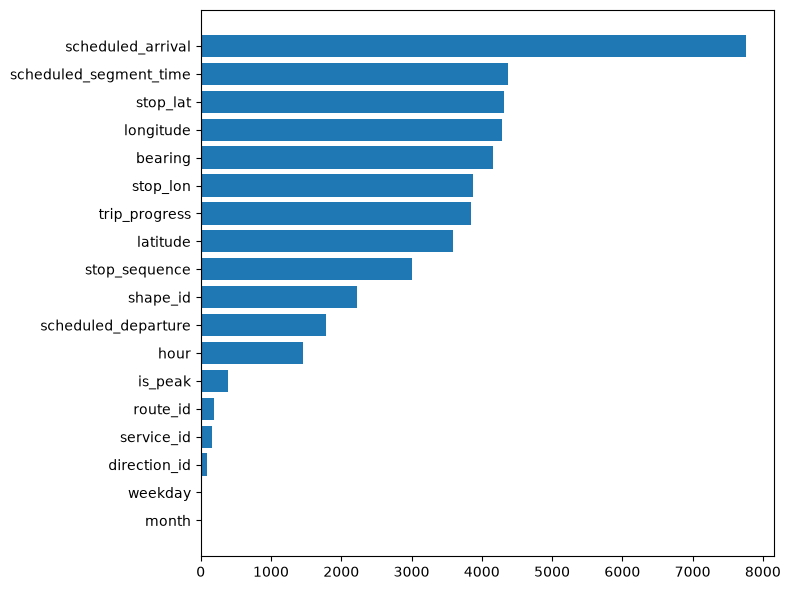

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

fi = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print(fi)

plt.figure(figsize=(8,6))
plt.barh(fi["Feature"], fi["Importance"])
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()